# 07b — Torus 3D version complète (Antoine)

Reproduction fidèle de la méthode MATLAB d'Antoine pour la **trajectoire de référence Fourier-fitted** + **ellipses 1σ/2σ/3σ** orientées localement par phase angle via les repères Frenet-Serret.

**Méthode** :
1. Reconstruction TDE (X[t], X[t+τ], X[t+2τ]) sur la baseline (hors perturbation)
2. Fit d'un plan moyen via polynôme poly11 → rotation pour aligner sur XY
3. Calcul de la phase angle (atan2 dans le plan projeté)
4. Fit Fourier ordre 8 (avec période doublée pour forcer périodicité) sur (X, Y, Z) en fonction de la phase
5. Échantillonnage à résolution 360 (1 point par degré) → `ref_traj` (360, 3)
6. Calcul des repères Frenet-Serret (T, N, B) le long de `ref_traj`
7. Calcul des std locales le long de N et B (proj des données expérimentales sur les repères)
8. Génération des ellipses 1σ/2σ/3σ orientées localement
9. Plot 3 sous-plots (silence / tempo / beatmove) avec la trajectoire perturbation en rouge

**Output** : `outputs/figures/fig4_torus_3d_full.png` (n'écrase pas le `fig4_torus_3d_simple.png` du 07a).

**Participant exemple** : `012WaCh` (signal le plus propre).

In [2]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
%matplotlib inline

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 100, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

FIG_DIR = Path(paths.OUTPUTS_DIR) / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLE_P = '012WaCh'
COND_ORDER = ['silence', 'tempo_random', 'beatmove_adaptatif']
COND_LABELS = {'silence': 'Silence', 'tempo_random': 'Tempo random', 'beatmove_adaptatif': 'BeatMove'}

# Charger params TDE
df_tde = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '04_tde_per_participant.csv')
tau_p = int(df_tde[df_tde['participant'] == EXAMPLE_P]['tau_p'].iloc[0])
m_p   = int(df_tde[df_tde['participant'] == EXAMPLE_P]['m_p'].iloc[0])
print(f"✅ Setup : {EXAMPLE_P}, τ={tau_p}, m={m_p}")

✅ Setup : 012WaCh, τ=16, m=4


## Fonctions Antoine portées en Python

In [3]:
def _fit_plane_poly11(x, y, z):
    """Fit plan z = p00 + p10*x + p01*y. Retourne coeffs [p00, p10, p01]."""
    A = np.column_stack([np.ones_like(x), x, y])
    coeffs, *_ = np.linalg.lstsq(A, z, rcond=None)
    return coeffs


def _rotation_to_align(a, b):
    """Matrice de rotation qui aligne a sur b (Rodrigues)."""
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    c = np.cross(a, b)
    angle = np.arccos(np.clip(np.dot(a, b), -1, 1))
    axis = c / (np.linalg.norm(c) + 1e-12)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K


def _fourier_design_matrix(phases_deg, order):
    phi = np.deg2rad(phases_deg).reshape(-1, 1)
    k = np.arange(1, order + 1).reshape(1, -1)
    return np.hstack([np.ones((len(phases_deg), 1)),
                      np.sin(phi * k), np.cos(phi * k)])


def fourier_reference_trajectory(XR_3d, fourier_order=8):
    """
    Calcule la trajectoire de référence Fourier-fitted dans l'espace de phase.

    Parameters
    ----------
    XR_3d : (N, 3) array — 3 premières colonnes de la reconstruction TDE
    fourier_order : ordre du fit Fourier (Antoine = 8)

    Returns
    -------
    ref_traj : (360, 3) trajectoire de référence (1 point par degré)
    phase_data : (M, 4) données triées par phase (x, y, z, phase_deg)
    """
    X, Y, Z = XR_3d[:, 0], XR_3d[:, 1], XR_3d[:, 2]
    Xo, Yo, Zo = np.nanmean(X), np.nanmean(Y), np.nanmean(Z)

    # Plan moyen
    coeffs = _fit_plane_poly11(X, Y, Z)
    normal_vec = np.array([-coeffs[1], -coeffs[2], 1.0])

    # Rotation pour aligner le plan moyen avec XY
    R = _rotation_to_align(np.array([0., 0., 1.]), normal_vec)
    proj = np.column_stack([X - Xo, Y - Yo, Z - Zo]) @ R

    # Phase angle = atan2 dans le plan projeté
    phase_pre = np.degrees(np.arctan2(proj[:, 1], proj[:, 0])) + 180
    idx_sorted = np.argsort(np.round(phase_pre))
    phase_sorted = np.round(phase_pre)[idx_sorted].astype(int) % 360

    Xs, Ys, Zs = X[idx_sorted], Y[idx_sorted], Z[idx_sorted]

    # Fit Fourier (doubler la période pour forcer la périodicité)
    phase_fit = np.concatenate([phase_sorted, phase_sorted + 360]).astype(float)
    x_fit = np.concatenate([Xs, Xs])
    y_fit = np.concatenate([Ys, Ys])
    z_fit = np.concatenate([Zs, Zs])

    valid = np.isfinite(phase_fit) & np.isfinite(x_fit) & np.isfinite(y_fit) & np.isfinite(z_fit)
    phase_fit, x_fit, y_fit, z_fit = phase_fit[valid], x_fit[valid], y_fit[valid], z_fit[valid]

    phase_ref = np.arange(360)
    A_fit = _fourier_design_matrix(phase_fit, fourier_order)
    A_ref = _fourier_design_matrix(phase_ref, fourier_order)

    bx, *_ = np.linalg.lstsq(A_fit, x_fit, rcond=None)
    by, *_ = np.linalg.lstsq(A_fit, y_fit, rcond=None)
    bz, *_ = np.linalg.lstsq(A_fit, z_fit, rcond=None)

    ref_traj = np.column_stack([A_ref @ bx, A_ref @ by, A_ref @ bz])
    phase_data = np.column_stack([Xs, Ys, Zs, phase_sorted])
    return ref_traj, phase_data


def compute_local_frames(ref_traj):
    """Frames Frenet-Serret (T, N, B) le long de la trajectoire de référence."""
    n = len(ref_traj)
    T, N, B = np.zeros((n, 3)), np.zeros((n, 3)), np.zeros((n, 3))

    def _norm(v):
        nrm = np.linalg.norm(v)
        return v / nrm if nrm > 1e-12 else v

    T[0] = _norm(ref_traj[1] - ref_traj[0])
    T[-1] = _norm(ref_traj[-1] - ref_traj[-2])
    for i in range(1, n - 1):
        T[i] = _norm(ref_traj[i + 1] - ref_traj[i - 1])

    N[0] = _norm(T[1] - T[0])
    N[-1] = _norm(T[-1] - T[-2])
    for i in range(1, n - 1):
        N[i] = _norm(T[i + 1] - T[i - 1])

    for i in range(n):
        B[i] = _norm(np.cross(T[i], N[i]))
    return T, N, B


def compute_local_std(ref_traj, phase_data):
    """Écarts-types locaux le long des axes Normal et Binormal."""
    n = len(ref_traj)
    T, N, B = compute_local_frames(ref_traj)
    std_n = np.full(n, np.nan)
    std_b = np.full(n, np.nan)

    for k in range(n):
        mask = phase_data[:, 3] == k
        if mask.sum() < 2:
            continue
        vecs = phase_data[mask, :3] - ref_traj[k]
        std_n[k] = np.nanstd(vecs @ N[k], ddof=1)
        std_b[k] = np.nanstd(vecs @ B[k], ddof=1)
    return std_n, std_b, N, B


def generate_ellipses(ref_traj, std_n, std_b, N, B, scale=1.0, n_pts=50):
    """Génère les ellipses locales orientées."""
    theta = np.linspace(0, 2 * np.pi, n_pts)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    ellipses = np.zeros((len(ref_traj), n_pts, 3))

    for i in range(len(ref_traj)):
        a, b = scale * std_n[i], scale * std_b[i]
        if np.isnan(a) or np.isnan(b):
            ellipses[i] = np.nan
            continue
        e = np.outer(a * cos_t, N[i]) + np.outer(b * sin_t, B[i])
        ellipses[i] = e + ref_traj[i]
    return ellipses

## Plot Fig 4 version complète (3 conditions, ellipses 1σ/2σ/3σ)

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_3880\4282209415.py:13: RuntimeWarning: Mean of empty slice
  sac_xy = np.nanmean(dos_xy, axis=0)



silence :
  std_n moyen = 5.29 mm  (smoothed = 5.29)
  std_b moyen = 5.75 mm  (smoothed = 5.75)
  couverture phase angles : 360/360

tempo_random :
  std_n moyen = 5.48 mm  (smoothed = 5.48)
  std_b moyen = 6.01 mm  (smoothed = 6.01)
  couverture phase angles : 360/360

beatmove_adaptatif :
  std_n moyen = 4.27 mm  (smoothed = 4.27)
  std_b moyen = 4.05 mm  (smoothed = 4.05)
  couverture phase angles : 360/360


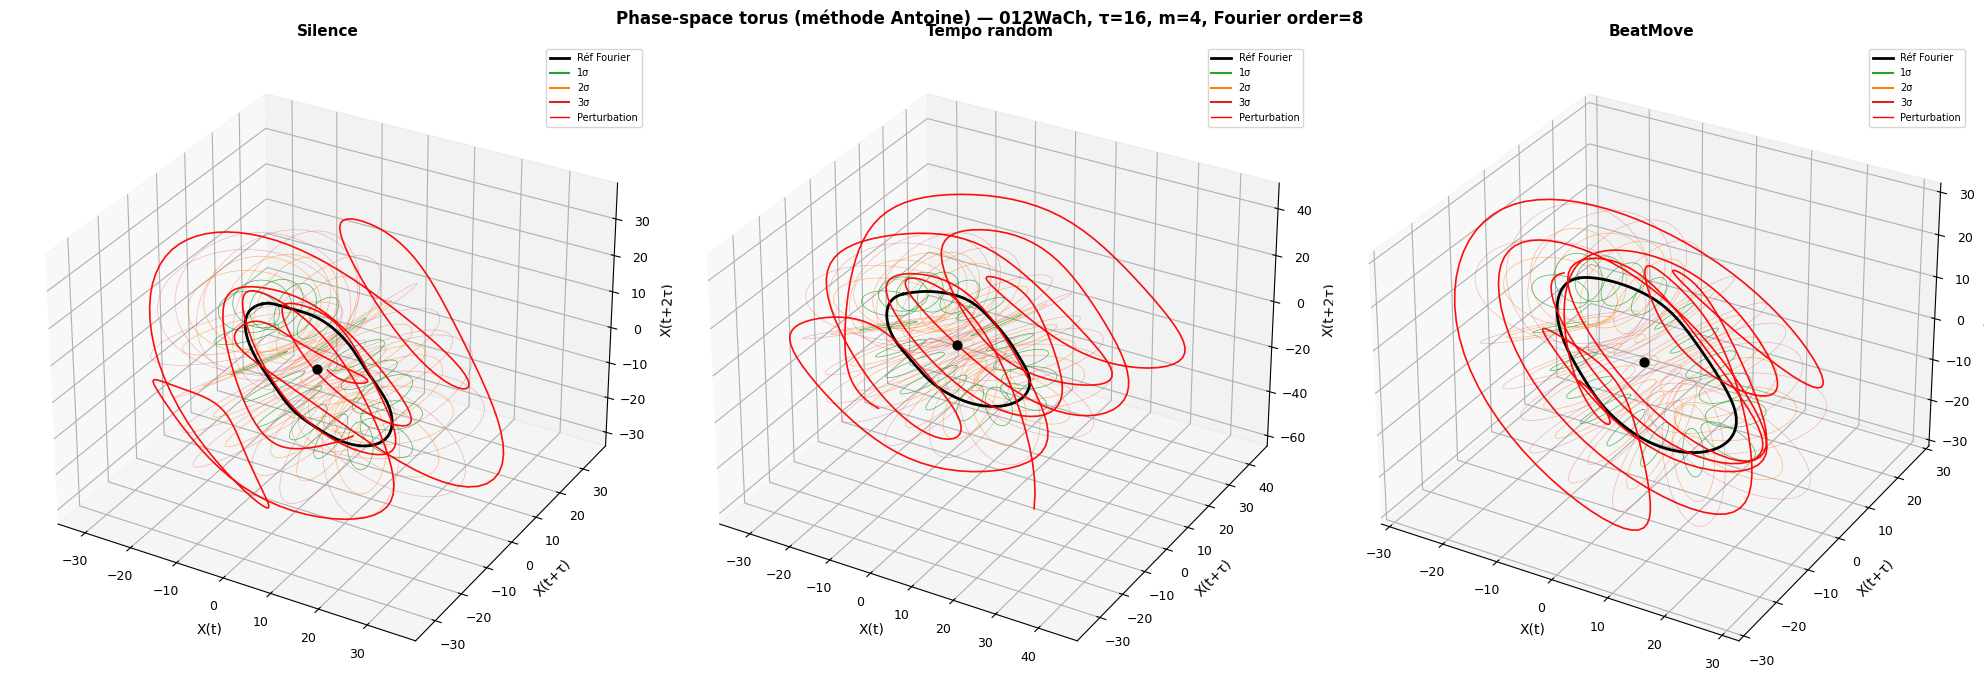


✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\fig4_torus_3d_full.png


In [4]:
SIGMA_COLORS = {1: '#2ca02c', 2: '#ff7f0e', 3: '#d62728'}  # vert / orange / rouge
SIGMA_ALPHAS = {1: 0.8, 2: 0.5, 3: 0.3}

fig = plt.figure(figsize=(20, 7))

for i, cond in enumerate(COND_ORDER):
    # Charger signal + détecter pert via bbox
    d = writer.load_processed(EXAMPLE_P, cond)
    sig = d['signal_final'].astype(float)
    t = d['time_final'].astype(float)

    dos_xy = np.stack([d[f'raw_Dos{j:02d}'][:, :2] for j in range(1, 5)], axis=0)
    sac_xy = np.nanmean(dos_xy, axis=0)
    for ax_idx in range(2):
        col = sac_xy[:, ax_idx]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sac_xy[:, ax_idx] = col
    det = detection.detect_sand_by_bbox(sac_xy)
    pert_entry, pert_exit = det['entry_t'], det['exit_t']

    # Reconstruction TDE (3 premières dims pour viz 3D)
    XR = tde.phase_space_reconstruction(sig, tau=tau_p, dim=m_p)[:, :3]
    pad = (m_p - 1) * tau_p
    t_xr = t[pad:pad + XR.shape[0]]
    pert_mask = (t_xr >= pert_entry) & (t_xr <= pert_exit)

    # Trajectoire de référence Fourier sur baseline
    XR_baseline = XR[~pert_mask]
    ref_traj, phase_data = fourier_reference_trajectory(XR_baseline, fourier_order=8)

    # Écarts-types locaux
    std_n, std_b, N, B = compute_local_std(ref_traj, phase_data)

    # Smoothing gaussien
    std_n_filled = np.nan_to_num(std_n, nan=np.nanmean(std_n))
    std_b_filled = np.nan_to_num(std_b, nan=np.nanmean(std_b))
    std_n_smooth = gaussian_filter1d(std_n_filled, sigma=5)
    std_b_smooth = gaussian_filter1d(std_b_filled, sigma=5)

    print(f"\n{cond} :")
    print(f"  std_n moyen = {np.nanmean(std_n):.2f} mm  (smoothed = {np.nanmean(std_n_smooth):.2f})")
    print(f"  std_b moyen = {np.nanmean(std_b):.2f} mm  (smoothed = {np.nanmean(std_b_smooth):.2f})")
    print(f"  couverture phase angles : {np.sum(~np.isnan(std_n))}/360")

    # Plot
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    # Ellipses 1σ, 2σ, 3σ (du plus grand au plus petit pour overlay)
    for sigma in [3, 2, 1]:
        ellipses = generate_ellipses(ref_traj, std_n_smooth, std_b_smooth,
                                       N, B, scale=sigma, n_pts=40)
        step = 20  # 1 ellipse tous les 20° pour pas surcharger
        for k in range(0, len(ellipses), step):
            if not np.isnan(ellipses[k]).any():
                ax.plot(ellipses[k, :, 0], ellipses[k, :, 1], ellipses[k, :, 2],
                        color=SIGMA_COLORS[sigma], alpha=SIGMA_ALPHAS[sigma],
                        linewidth=0.5)

    # Trajectoire de référence Fourier (épaisse noire)
    ax.plot(ref_traj[:, 0], ref_traj[:, 1], ref_traj[:, 2],
            color='black', linewidth=2, label='Réf Fourier')

    # Trajectoire perturbation (rouge)
    ax.plot(XR[pert_mask, 0], XR[pert_mask, 1], XR[pert_mask, 2],
            color='red', linewidth=1.2, alpha=0.95, label='Perturbation')

    # Centroïde
    ax.scatter(*XR_baseline.mean(axis=0), color='black', s=40, zorder=5)

    ax.set_title(COND_LABELS[cond], fontweight='bold')
    ax.set_xlabel('X(t)')
    ax.set_ylabel('X(t+τ)')
    ax.set_zlabel('X(t+2τ)')

    # Legend manuelle
    legend_lines = [
        Line2D([0], [0], color='black', linewidth=2, label='Réf Fourier'),
        Line2D([0], [0], color=SIGMA_COLORS[1], label='1σ'),
        Line2D([0], [0], color=SIGMA_COLORS[2], label='2σ'),
        Line2D([0], [0], color=SIGMA_COLORS[3], label='3σ'),
        Line2D([0], [0], color='red', linewidth=1, label='Perturbation'),
    ]
    ax.legend(handles=legend_lines, fontsize=7, loc='upper right')

plt.suptitle(f'Phase-space torus (méthode Antoine) — {EXAMPLE_P}, τ={tau_p}, m={m_p}, Fourier order=8',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_torus_3d_full.png')
plt.show()

print(f"\n✅ Figure sauvegardée : {FIG_DIR / 'fig4_torus_3d_full.png'}")

## Notes

**Reproduction fidèle de la méthode MATLAB d'Antoine**, portée en Python :
- `fct_create_fit1.m` → `_fit_plane_poly11()`
- `compute_local_frames.m` → `compute_local_frames()` (Frenet-Serret)
- `compute_local_std.m` → `compute_local_std()`
- `fct_ellipse_orientation_local.m` → `generate_ellipses()`
- Fit Fourier ordre 8 sur période doublée → fidèle
- Gaussian smoothing des std locales → fidèle

**Différences mineures vs MATLAB** :
- Phase angles arrondis modulo 360 (peut produire 360 ≡ 0 que MATLAB gère différemment)
- Smoothing sigma=5 (en samples sur 360) au lieu de la fenêtre 30 d'Antoine — équivalent visuel

**Interprétation visuelle attendue** :
- Trajectoire de référence noire = "cycle de marche moyen" dans l'espace de phase
- Ellipses concentriques 1σ (vert) / 2σ (orange) / 3σ (rouge pâle) = enveloppes de variabilité normale
- Trajectoire rouge = passage dans le bac → doit "sortir" des 2-3σ quand la perturbation est forte
- Comparaison sil/tem/bea : la trajectoire pert sort plus largement sous tempo_random qu'avec beatmove

**Pour la défense (slides Netlify)** : screenshot de cette figure ou export en SVG via `plt.savefig('fig.svg')`.